## Проект

Вы — аналитик данных, и сейчас идёте в стартап, который создает новый маркетплейс. Он недавно появился на рынке и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу.

Продакт-менеджер Петя переживает за свой продукт, так как выручка маркетплейса стоит на месте уже несколько месяцев. Он предложил вам полную свободу действий. Главное — чтобы метрики росли, а мы не причиняли неудобства клиентам, ведь Петя заботится об их опыте.

## Задачи
Вы поразмышляли и сформулировали список задач:

- Задача 1: Оценить месячный retention в оформление заказа с помощью когортного анализа.
- Задача 2: Определить, существует ли product/market fit у этого маркетплейса.
- Задача 3: Определить 5 основных метрик, на которых продакту можно сконцентрироваться, чтобы максимизировать прибыль компании.
- Задача 4: Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.
- Задача 5: Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.
- Задача 6: Сформулировать выводы о проделанной работе и составить отчет.


## Данные

| Файл | Описание |
|------|----------|
| `olist_customers_dataset.csv` | Информация о пользователях |
| `olist_orders_dataset.csv` | Информация о заказах |
| `olist_order_items_dataset.csv` | Товарные позиции в заказах |

### Ключевые таблицы

#### Customers

| Поле | Описание |
|------|----------|
| `customer_id` | Идентификатор заказа (позаказный) |
| `customer_unique_id` | Уникальный идентификатор пользователя |
| `customer_city` | Город |
| `customer_state` | Штат |

#### Orders

| Поле | Описание |
|------|----------|
| `order_id` | Уникальный идентификатор заказа |
| `customer_id` | Идентификатор пользователя |
| `order_status` | Статус заказа |
| `order_purchase_timestamp` | Время создания заказа |
| `order_delivered_customer_date` | Время доставки |

#### Order Items

| Поле | Описание |
|------|----------|
| `order_id` | Идентификатор заказа |
| `product_id` | Идентификатор товара |
| `price` | Цена за единицу |
| `freight_value` | Стоимость доставки |

### Статусы заказов

| Статус | Описание |
|--------|----------|
| `created` | Создан |
| `approved` | Подтверждён |
| `invoiced` | Выставлен счёт |
| `processing` | В процессе сборки |
| `shipped` | Отгружён |
| `delivered` | Доставлен |
| `unavailable` | Отменён (товар недоступен) |
| `canceled` | Отменён |



## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

- Исследовать датасет и определить, какой вид заказа будет учитываться в retention
- Построить месячный retention
- Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)
- Найти когорту с самым высоким retention на 3-й месяц.
- Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

In [36]:
import pandas as pd 

In [151]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv', parse_dates=[3,4,5,6,7])
order_items = pd.read_csv('olist_order_items_dataset.csv')

In [152]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [153]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [154]:
customers.customer_unique_id.nunique()

96096

In [155]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [156]:
customers.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [157]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [158]:
orders.order_id.nunique()

99441

In [159]:
orders.query('order_status == "delivered"').shape[0]

96478

In [160]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [161]:
orders_by_customer = pd.merge(customers , orders, on= 'customer_id', how='left')
orders_by_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15


In [162]:
orders_by_customer.groupby('customer_unique_id').order_id.count().mean()

np.float64(1.0348089410589412)

mean = 1.0348 — в среднем каждый пользователь делает всего 1.03 заказа.


In [163]:
import seaborn as sns

In [164]:
orders_by_customer.isna().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [165]:
print("Уникальных пользователей в customers:", customers['customer_unique_id'].nunique())
print("Уникальных пользователей в orders (по customer_id):", orders['customer_id'].nunique())
print("Уникальных заказов:", orders['order_id'].nunique())

Уникальных пользователей в customers: 96096
Уникальных пользователей в orders (по customer_id): 99441
Уникальных заказов: 99441


In [166]:
orders_by_customer.order_status.value_counts(normalize=True)

order_status
delivered      0.970203
shipped        0.011132
canceled       0.006285
unavailable    0.006124
invoiced       0.003158
processing     0.003027
created        0.000050
approved       0.000020
Name: proportion, dtype: float64

Для расчёта retention учитываются все оформленные заказы независимо от их дальнейшего статуса, поскольку исследуется возвращаемость пользователей именно к оформлению заказа.

In [167]:
cohort_month = orders_by_customer.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index() 
cohort_month.order_purchase_timestamp = cohort_month.order_purchase_timestamp.dt.to_period('M')
cohort_month = cohort_month.rename(columns={
    'order_purchase_timestamp': 'cohort_month'
})
cohort_month

,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06
96092,fffea47cd6d3cc0a88bd621562a9d061,2017-12
96093,ffff371b4d645b6ecea244b27531430a,2017-02
96094,ffff5962728ec6157033ef9805bacc48,2018-05


In [168]:
orders_by_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15


In [169]:
orders_by_customer['order_month'] = orders_by_customer.order_purchase_timestamp.dt.to_period('M')

In [170]:
orders_by_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07


In [171]:
cohort_data = orders_by_customer.merge(cohort_month, how='left', on='customer_unique_id')
cohort_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,cohort_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07,2018-07


In [172]:
cohort_data['cohort_index'] = cohort_data.order_month.dt.year *12 + cohort_data.order_month.dt.month \
                                            - cohort_data.cohort_month.dt.year *12 - cohort_data.cohort_month.dt.month

In [173]:
cohort_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,cohort_month,cohort_index
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05,2017-05,0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01,2018-01,0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05,2018-05,0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03,2018-03,0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07,2018-07,0


In [174]:
cohort_counts = cohort_data.groupby(['cohort_month', 'cohort_index']).customer_unique_id.nunique().reset_index()
cohort_counts.head()

,cohort_month,cohort_index,customer_unique_id
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1


In [175]:
cohort_matrix = cohort_counts.pivot(columns = 'cohort_index', index = 'cohort_month', values = 'customer_unique_id')#.fillna(0)
cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [176]:
cohort_matrix_percent = cohort_matrix.div(cohort_matrix[0], axis=0) * 100

In [177]:
cohort_matrix_percent

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.311526,NaN,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,NaN,0.311526,0.623053,0.623053
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.392670,0.261780,0.130890,0.392670,0.130890,0.523560,0.130890,0.130890,NaN,0.392670,0.130890,0.785340,0.392670,0.130890,0.130890,0.261780,0.392670,0.130890,NaN
2017-02,100.0,0.228311,0.285388,0.114155,0.399543,0.114155,0.228311,0.171233,0.171233,0.228311,0.114155,0.285388,0.171233,0.171233,0.114155,0.057078,0.057078,0.228311,NaN,NaN
2017-03,100.0,0.493171,0.379363,0.379363,0.341426,0.151745,0.151745,0.303490,0.341426,0.075873,0.379363,0.151745,0.227618,0.113809,0.151745,0.227618,0.075873,0.151745,NaN,NaN
2017-04,100.0,0.595238,0.212585,0.170068,0.340136,0.255102,0.340136,0.297619,0.297619,0.170068,0.255102,0.085034,0.085034,0.042517,0.085034,0.085034,0.212585,NaN,NaN,NaN
2017-05,100.0,0.500556,0.500556,0.389321,0.305895,0.333704,0.417130,0.166852,0.250278,0.305895,0.250278,0.333704,0.250278,0.027809,0.194661,0.250278,NaN,NaN,NaN,NaN
2017-06,100.0,0.477859,0.350430,0.414145,0.254858,0.382287,0.382287,0.223001,0.127429,0.223001,0.318573,0.350430,0.159286,0.127429,0.191144,NaN,NaN,NaN,NaN,NaN


In [178]:
cohort_matrix_percent[1].median()

0.5005561735261401

Для типичной месячной когорты примерно 0.5% пользователей возвращаются и оформляют новый заказ через месяц после первой покупки.

In [179]:
cohort_matrix_percent[3].max()

0.41414463204842306

In [180]:
cohort_matrix_percent[3].idxmax()

Period('2017-06', 'M')

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(170.72222222222223, 0.5, 'Месяц первой покупки')

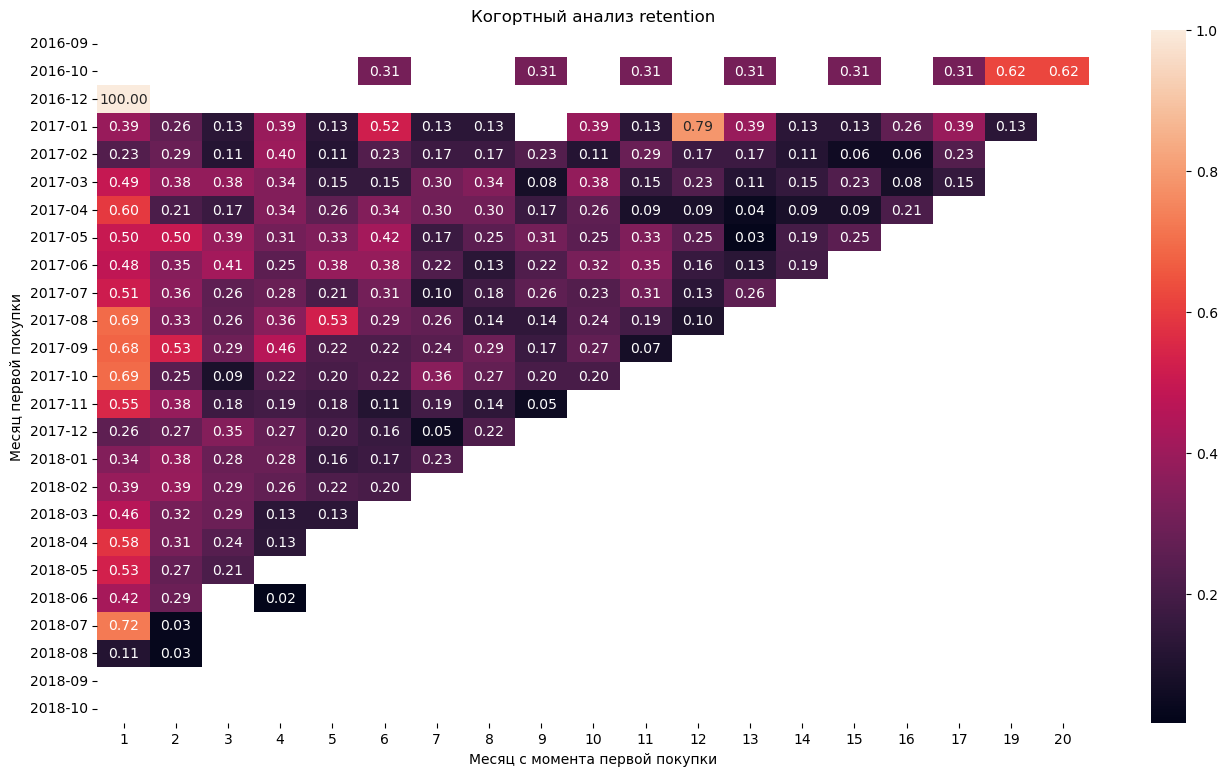

In [182]:
plt.figure(figsize=(16, 9))
sns.heatmap(cohort_matrix_percent.iloc[:, 1:], vmax = 1, annot = True, fmt='.2f')
plt.title('Когортный анализ retention')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Месяц первой покупки')

Медианный retention первого месяца составляет примерно 0,5%, то есть уже через месяц возвращается очень небольшая доля пользователей. Наибольший retention третьего месяца наблюдается у когорты июня 2017 года и составляет около 0,4%. В целом по когортам возвращаемость пользователей остаётся низкой, при этом явного тренда на её улучшение со временем не наблюдается. Причины такого низкого retention на данном этапе анализа определить нельзя — для этого потребуется дополнительное исследование поведения пользователей и других метрик продукта.

## Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

- Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
- Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону - лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
- Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

По когортному анализу выраженного product/market fit не наблюдается: retention остаётся очень низким и устойчивого плато не формируется. Значит, пока не видно стабильного ядра пользователей, регулярно возвращающихся в продукт. Перед масштабированием маркетплейсу следует понять причины слабой повторной активности.

In [183]:
cohort_matrix_percent.median()

cohort_index
0     100.000000
1       0.500556
2       0.314392
3       0.262906
4       0.282486
5       0.201342
6       0.228311
7       0.223001
8       0.199231
9       0.201342
10      0.252690
11      0.238296
12      0.165260
13      0.149331
14      0.141318
15      0.179254
16      0.144229
17      0.269918
19      0.376972
20      0.623053
dtype: float64

<Axes: xlabel='cohort_index'>

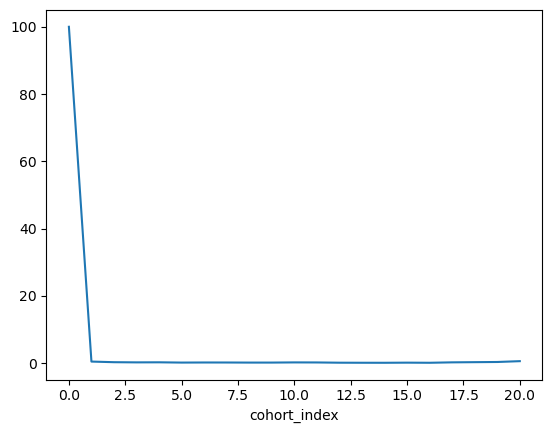

In [200]:
sns.lineplot(cohort_matrix_percent.median())

In [185]:
orders_by_customer

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,2018-04
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,2018-04
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,2018-04
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,2017-11


In [186]:
orders_by_customer.order_approved_at - orders_by_customer.order_purchase_timestamp

0       0 days 00:16:37
1       0 days 00:10:08
2       1 days 00:11:25
3       0 days 01:22:41
4       0 days 00:18:39
              ...      
99436   0 days 00:20:28
99437   0 days 00:14:50
99438   0 days 00:18:13
99439   0 days 00:22:47
99440   0 days 04:23:16
Length: 99441, dtype: timedelta64[ns]

In [187]:
delivery = orders.query("order_status == 'delivered'").copy()

In [188]:
delivery['purchase_to_approved'] = (
    delivery.order_approved_at - delivery.order_purchase_timestamp
).dt.total_seconds() / 86400

delivery['approved_to_carrier'] = (
    delivery.order_delivered_carrier_date - delivery.order_approved_at
).dt.total_seconds() / 86400

delivery['carrier_to_customer'] = (
    delivery.order_delivered_customer_date - delivery.order_delivered_carrier_date
).dt.total_seconds() / 86400

delivery['total_delivery_time'] = (
    delivery.order_delivered_customer_date - delivery.order_purchase_timestamp
).dt.total_seconds() / 86400

In [189]:
delivery['delivery_delay'] = (
    delivery.order_delivered_customer_date - delivery.order_estimated_delivery_date
).dt.total_seconds() / 86400

In [190]:
delivery[[
    'purchase_to_approved',
    'approved_to_carrier',
    'carrier_to_customer',
    'total_delivery_time',
    'delivery_delay'
]].median()

purchase_to_approved     0.014306
approved_to_carrier      1.815845
carrier_to_customer      7.099769
total_delivery_time     10.217477
delivery_delay         -11.948102
dtype: float64

In [191]:
delivery[[
    'purchase_to_approved',
    'approved_to_carrier',
    'carrier_to_customer',
    'total_delivery_time',
    'delivery_delay'
]].quantile([0.5, 0.75, 0.9])

,purchase_to_approved,approved_to_carrier,carrier_to_customer,total_delivery_time,delivery_delay
0.50,0.014306,1.815845,7.099769,10.217477,-11.948102
0.75,0.604774,3.575009,12.028646,15.720182,-6.389815
0.90,1.441382,5.990515,18.897808,23.096377,-1.137531


In [192]:
(delivery.delivery_delay > 0).mean() * 100

np.float64(8.111693857667031)

Доставка сама по себе достаточно длительная — медиана около 10 дней, однако большинство заказов доставляется раньше обещанного срока. Только около 8% заказов доставляются с опозданием. Следовательно, массовое нарушение обещанных сроков доставки вряд ли является основной причиной крайне низкого retention.

In [194]:
first_orders = (
    orders_by_customer
    .sort_values('order_purchase_timestamp')
    .drop_duplicates(subset='customer_unique_id', keep='first')
)

In [195]:
orders_count = (
    orders_by_customer
    .groupby('customer_unique_id')
    .order_id
    .nunique()
    .reset_index(name='orders_count')
)

orders_count['returned'] = orders_count.orders_count > 1

In [196]:
first_orders = first_orders.merge(
    orders_count[['customer_unique_id', 'returned']],
    on='customer_unique_id',
    how='left'
)

In [197]:
first_delivered = first_orders.query("order_status == 'delivered'").copy()

first_delivered['delivery_time'] = (
    first_delivered.order_delivered_customer_date
    - first_delivered.order_purchase_timestamp
).dt.total_seconds() / 86400

first_delivered['delivery_delay'] = (
    first_delivered.order_delivered_customer_date
    - first_delivered.order_estimated_delivery_date
).dt.total_seconds() / 86400

first_delivered['late_delivery'] = first_delivered.delivery_delay > 0

In [198]:
first_delivered.groupby('late_delivery').returned.mean() * 100

late_delivery
False    3.129706
True     2.568493
Name: returned, dtype: float64

In [199]:
first_delivered.groupby('late_delivery').customer_unique_id.nunique()

late_delivery
False    85663
True      7592
Name: customer_unique_id, dtype: int64

Пользователи, столкнувшиеся с опозданием первого заказа, возвращаются реже. Это указывает на возможную связь между качеством доставки и повторной покупкой. Однако по этому анализу нельзя утверждать, что именно опоздание является причиной снижения retention.

По результатам когортного анализа выраженного product/market fit у маркетплейса не наблюдается. Retention после первой покупки находится на низком уровне и не выходит на устойчивое плато, поэтому не видно сформировавшегося ядра пользователей, которые регулярно возвращаются в продукт. В связи с этим масштабирование на новые рынки на текущем этапе может привести преимущественно к росту числа одноразовых покупателей.
Причина низкого retention однозначно не определяется имеющимися данными. Возможными факторами являются недостаточная повторная ценность продукта, ассортимент и естественная частота покупки товаров, а также клиентский опыт. Анализ доставки показал, что массовых проблем с выполнением заказов не наблюдается, хотя пользователи с просроченной первой доставкой возвращаются несколько реже.
Поэтому в ближайшее время маркетплейсу стоит сосредоточиться на изучении причин низкой повторной активности и улучшении retention, а к масштабированию переходить после появления устойчивого сегмента возвращающихся пользователей.

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

- Первая метрика должна отражать рост объёма продаж маркетплейса.
- Вторая — показывать объем аудитории, которой продукт доставляет ценность.
- Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).
- Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
- Пятая — отражать денежное выражение вовлеченности клиента.
Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

In [201]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [202]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [205]:
orders_with_price = orders.merge(order_items, how='left', on='order_id')
orders_with_price['order_month'] = orders_with_price.order_purchase_timestamp.dt.to_period('M')
orders_with_price.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [217]:
monthly_gmv = orders_with_price.query('order_status == "delivered"').groupby('order_month').price.sum().reset_index()
monthly_gmv

,order_month,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


Text(0, 0.5, 'GMV')

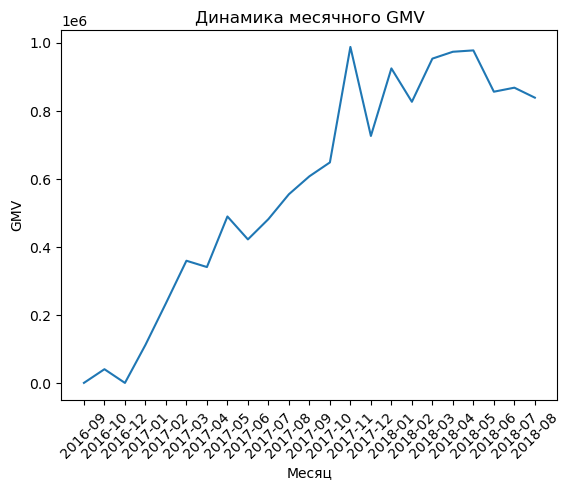

In [226]:
monthly_gmv['order_month'] = monthly_gmv['order_month'].astype(str)
sns.lineplot(data = monthly_gmv ,x = 'order_month', y = 'price')
plt.xticks(rotation=45);
plt.title('Динамика месячного GMV')
plt.xlabel('Месяц')
plt.ylabel('GMV')

Вторая — показывать объем аудитории, которой продукт доставляет ценность.

In [228]:
orders_by_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07


In [233]:
monthly_mau = orders_by_customer.query('order_status == "delivered"').groupby('order_month').customer_unique_id.nunique().reset_index()
monthly_mau

,order_month,customer_unique_id
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630
5,2017-03,2508
6,2017-04,2274
7,2017-05,3479
8,2017-06,3076
9,2017-07,3802


Text(0, 0.5, 'MAU')

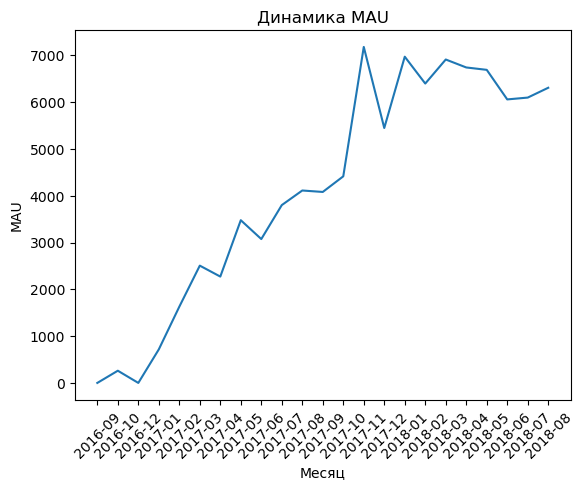

In [240]:
monthly_mau['order_month'] = monthly_mau['order_month'].astype(str)
sns.lineplot(data = monthly_mau ,x = 'order_month', y = 'customer_unique_id')
plt.xticks(rotation=45);
plt.title('Динамика MAU')
plt.xlabel('Месяц')
plt.ylabel('MAU')

Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных)

Conversion Rate в первую покупку — доля новых пользователей, совершивших первый заказ. Метрика отражает заинтересованность новой аудитории в продукте. На текущих данных не рассчитывается из-за отсутствия данных о посещениях.

Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.

Monthly Retention Rate — доля пользователей, которые после первой покупки возвращаются и совершают новый заказ в последующие месяцы. Метрика показывает, насколько продукт удерживает клиентов и формирует повторное использование.

Text(170.72222222222223, 0.5, 'Месяц первой покупки')

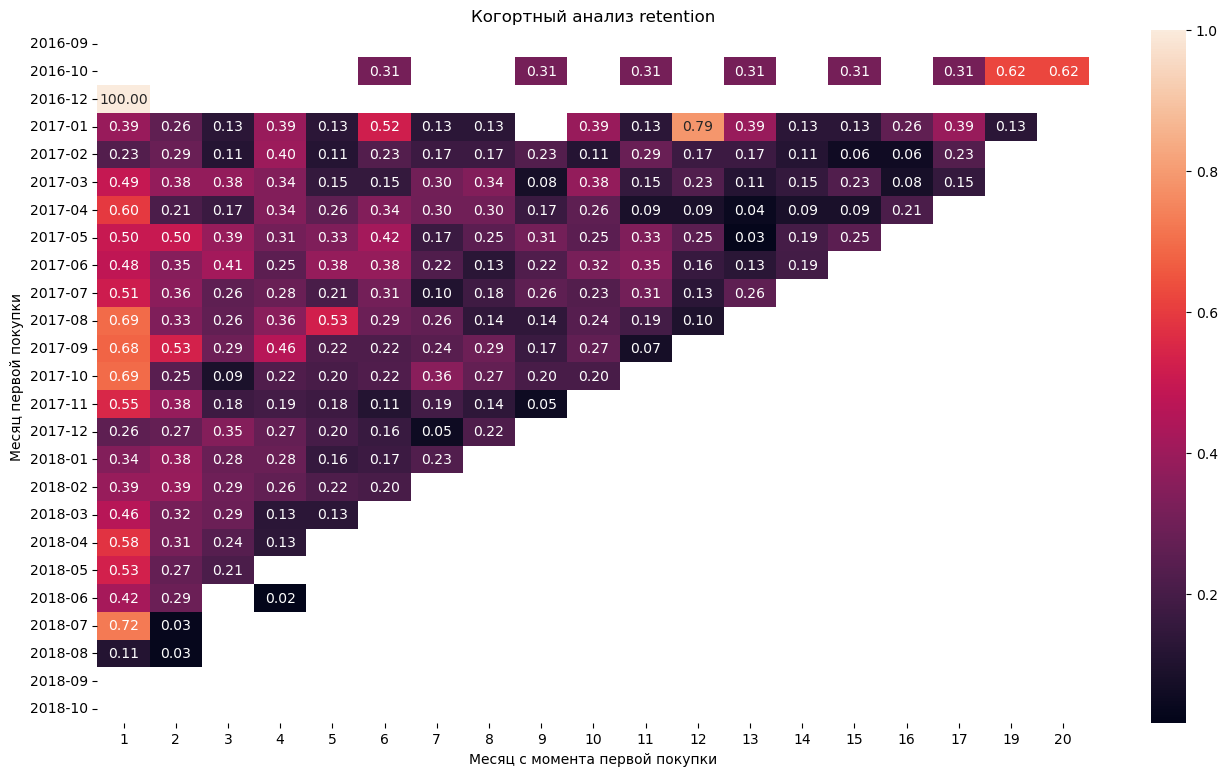

In [236]:
plt.figure(figsize=(16, 9))
sns.heatmap(cohort_matrix_percent.iloc[:, 1:], vmax = 1, annot = True, fmt='.2f')
plt.title('Когортный анализ retention')
plt.xlabel('Месяц с момента первой покупки')
plt.ylabel('Месяц первой покупки')

In [242]:
monthly_metrics = monthly_gmv.merge(monthly_mau, on = 'order_month')
monthly_metrics['avg_gmv_per_user'] = monthly_metrics.price / monthly_metrics.customer_unique_id
monthly_metrics

,order_month,price,customer_unique_id,avg_gmv_per_user
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


Text(0, 0.5, 'Средний GMV на пользователя')

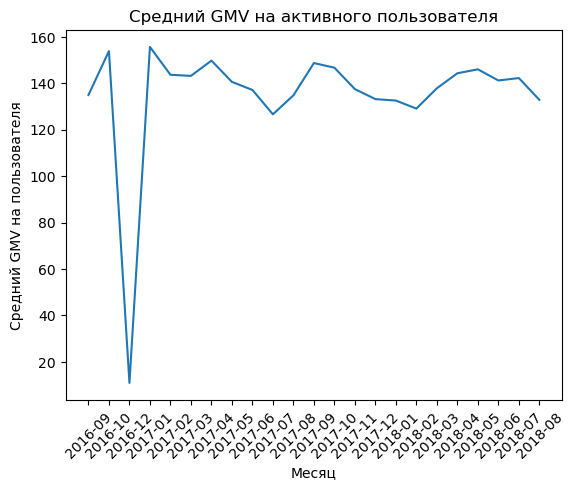

In [244]:
monthly_metrics['order_month'] = monthly_metrics['order_month'].astype(str)
sns.lineplot(data = monthly_metrics ,x = 'order_month', y = 'avg_gmv_per_user')
plt.xticks(rotation=45);
plt.title('Средний GMV на активного пользователя')
plt.xlabel('Месяц')
plt.ylabel('Средний GMV на пользователя')

Средний GMV на активного пользователя за месяц — отношение месячного GMV к количеству активных покупателей за этот месяц. Метрика показывает денежное выражение вовлечённости пользователя: сколько в среднем покупок в денежном выражении приходится на одного активного клиента. В рассматриваемый период показатель в основном находится на уровне около 130–150 и не демонстрирует выраженного устойчивого роста.

## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать.

Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по `Ease` и `Confidence`.

Вам нужно заполнить самый важный показатель — `Impact`.

Для этого вам требуется выбрать одну из трёх основных гипотез с помощью фреймворка **ICE**, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта `Impact` возьмите данные с июня 2017 года.

Считайте, что конверсия в повторный заказ равна величине медианного `retention` 1-го месяца (см. пункт 1 проекта).

Для перевода метрики в `Impact` воспользуйтесь следующей шкалой:

| Impact | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Значение метрики | 0–50 | 51–150 | 151–350 | 351–750 | 751–1550 | 1551–3150 | 3151–6350 | 6351–12750 | 12751–25550 | 25551–51150 |

### Гипотезы

| Гипотеза | Impact | Confidence | Ease | ICE |
|---|---:|---:|---:|---:|
| Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. |  | 8 | 6 |  |
| Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. |  | 10 | 4 |  |
| Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ. |  |  5|9  |  |

In [245]:
orders.query(
    'order_purchase_timestamp >= "2017-06-01" and order_status == "canceled"'
).order_id.nunique()

499

## Гипотеза 1
По шкале Impact значение 499 попадает в диапазон **351–750**, поэтому:

**Impact = 4**
При `Confidence = 8` и `Ease = 6`
Итоговый ICE для первой гипотезы: **192**.

In [246]:
late_customers = orders_by_customer.query(
    'order_purchase_timestamp >= "2017-06-01" and '
    'order_status == "delivered" and '
    'order_delivered_customer_date > order_estimated_delivery_date'
).customer_unique_id.nunique()

late_customers

7245

In [247]:
median_retention_m1 = cohort_matrix_percent[1].median() / 100

additional_repeat_orders = late_customers * median_retention_m1

additional_repeat_orders

36.265294771968854

## Гипотеза 2

По шкале Impact значение 36.27 попадает в диапазон **0–50**, поэтому:

**Impact = 1**

При `Confidence = 10` и `Ease = 4` итоговый ICE:
Итоговый ICE для второй гипотезы: **40**.

In [249]:
orders_per_customer = (
    orders_by_customer
    .query('order_purchase_timestamp >= "2017-06-01"')
    .groupby('customer_unique_id')
    .order_id
    .nunique()
    .reset_index(name='orders_count')
)

In [250]:
one_time_customers = orders_per_customer.query('orders_count == 1').customer_unique_id.nunique()

one_time_customers

82559

In [251]:
additional_repeat_orders_3 = one_time_customers * median_retention_m1

additional_repeat_orders_3

413.25417130144604

## Гипотеза 3

По шкале Impact значение 413.25 попадает в диапазон **351–750**, поэтому:

**Impact = 4**

При `Confidence = 5` и `Ease = 9` итоговый ICE:
Итоговый ICE для третьей гипотезы: **180**.

## Вывод

По результатам расчёта ICE наибольший приоритет получила **гипотеза 1 — исправление бага в системе процессинга заказов**.

Полученные значения ICE:

- гипотеза 1 — **192**
- гипотеза 2 — **40**
- гипотеза 3 — **180**

Несмотря на то что третья гипотеза также имеет высокий потенциальный эффект, первая гипотеза набрала максимальный ICE за счёт сочетания достаточно высокого Impact, Confidence и Ease.

Поэтому в первую очередь команде стоит проверить и реализовать гипотезу об устранении отмен заказов в системе процессинга.

## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

- Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
- Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

### Задача 5. Метрики для проверки выбранной гипотезы

В качестве основной была выбрана гипотеза об исправлении бага в системе процессинга заказов, который приводит к отменам.

#### Целевая метрика — доля успешно доставленных заказов

Гипотеза предполагает, что после устранения причины отмен больше заказов будет успешно доходить до клиента. Поэтому рост доли доставленных заказов напрямую отражает ожидаемый эффект изменения.

#### Прокси-метрика — Cancellation Rate


Эта метрика непосредственно связана с исправляемой проблемой. Если изменение действительно устраняет баг в процессинге, доля отменённых заказов должна снизиться. При этом данную метрику можно наблюдать раньше, чем итоговую доставку заказа.

#### Guardrail-метрика — доля просроченных доставок


Необходимо убедиться, что увеличение количества успешно обработанных заказов не перегружает дальнейшие этапы выполнения заказа и не ухудшает качество доставки. Поэтому доля просроченных доставок в тестовой группе не должна существенно увеличиться.

Таким образом, успешным результатом A/B-теста будет одновременное увеличение доли успешно доставленных заказов и снижение доли отмен при отсутствии ухудшения сроков доставки.

# Итоговый отчёт

## Формализация проблемы продукта

Основная проблема маркетплейса — отсутствие устойчивого роста продукта. Несмотря на рост аудитории и объёма продаж на раннем этапе, в дальнейшем основные показатели выходят на плато.

Когортный анализ показал очень низкую повторную активность пользователей: медианный retention первого месяца составляет около **0.5%**. После первой покупки подавляющее большинство клиентов не возвращается за повторным заказом. При этом на retention-кривой не наблюдается выраженного устойчивого ядра возвращающихся пользователей.

Таким образом, основной проблемой продукта можно считать **низкое удержание клиентов и слабую повторную активность**. По имеющимся данным выраженного Product/Market Fit не наблюдается.

## Общие выводы исследования

В ходе исследования были проанализированы retention, продуктовые метрики и возможные направления улучшения продукта.

Когортный анализ показал, что после первой покупки retention резко снижается и остаётся на низком уровне. Медианный retention первого месяца составляет около **0.5%**, поэтому маркетплейс в основном привлекает одноразовых покупателей.

При анализе основных продуктовых метрик было выявлено, что:

- **GMV** активно рос в течение 2017 года, однако в 2018 году рост замедлился, и показатель в основном колеблется около сформировавшегося уровня;
- **MAU** также рос вместе с продуктом, но затем стабилизировался примерно на уровне **6–7 тыс. активных покупателей в месяц**;
- конверсию новых посетителей в первую покупку на имеющихся данных рассчитать нельзя, так как отсутствуют данные о посещениях маркетплейса;
- **Retention Rate** остаётся низким, что указывает на проблему с повторным использованием продукта;
- средний **GMV на активного пользователя** в основном находится примерно на уровне **130–150** и также не показывает устойчивого роста.

Дополнительно был рассмотрен клиентский опыт доставки. Массовые задержки относительно обещанного срока не выглядят основной причиной низкого retention, однако пользователи, столкнувшиеся с задержкой первой доставки, возвращаются несколько реже. Поэтому качество доставки может быть одним из факторов, влияющих на повторные покупки, но имеющихся данных недостаточно, чтобы считать его основной причиной.

Для выбора направления развития были оценены три гипотезы с помощью ICE:

- исправление бага, приводящего к отмене заказов — **ICE = 192**;
- сокращение времени до отгрузки — **ICE = 40**;
- добавление нового способа оплаты — **ICE = 180**.

Наибольший ICE получила гипотеза об **исправлении бага в системе процессинга заказов**, поэтому именно её предлагается проверить в первую очередь.

Для A/B-теста были выбраны следующие метрики:

- **целевая метрика:** доля успешно доставленных заказов;
- **прокси-метрика:** доля отменённых заказов;
- **guardrail-метрика:** доля заказов, доставленных позже обещанного срока.

## Рекомендации по продукту

На текущем этапе не стоит делать основной акцент только на дальнейшем масштабировании и привлечении новых пользователей. Прежде всего необходимо разобраться с причинами низкой повторной активности и повысить ценность продукта для уже привлечённых клиентов.

В первую очередь рекомендуется провести A/B-тест исправления бага в процессинге заказов. Ожидаемый результат — снижение доли отменённых заказов и увеличение доли успешно доставленных заказов без ухудшения сроков доставки.

После этого необходимо продолжить исследование причин низкого retention: изучить ассортимент и частоту покупки разных категорий товаров, пользовательский путь после первой покупки, причины отказа от повторного заказа и другие элементы клиентского опыта.

Главная задача продукта на следующем этапе — сформировать устойчивый сегмент возвращающихся покупателей. После появления стабильного retention и возобновления роста ключевых продуктовых метрик можно будет увереннее масштабировать маркетплейс.